# Interact with the pipeline

Although you can use a configuration file to create a pipeline, you can also interact with an existing pipelina and change some parameters

## Import dependencies

In [21]:
%load_ext autoreload
%autoreload 2
from paidiverpy.colour_layer import ColourLayer
from paidiverpy.pipeline import Pipeline
from paidiverpy.sampling_layer import SamplingLayer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Instantiate the class

In this specific dataset, you can see some warnings. It is related to the lack of some of metadata information

In [22]:
pipeline = Pipeline(config_file_path="../config_files/config_plankton.yml")

In [23]:
pipeline

In [24]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "plankton_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/plankton_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/plankton_csv/metadata/metadata_plankton_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "BMP",
        "n_jobs": 1,
        "track_changes": true,
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 0.9,
                    "raise_error": false
                },
                "mode": "percent"
            }
        ]
    },
    "steps": [
        {
            "name": "deblur",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "wiener",
                "psf_type": "gaussian",
                "sigma": 1,
                "angle": 45,
                "raise_error": false
            },
            "mode": "deblur"
        },
        {
            "name": "edge_detection",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "scharr",
                "blur_radius": 3,
                "threshold": {
                    "low": 2.5,
                    "high": 3.0
                },
                "object_type": "isolated",
                "object_selection": "largest_area",
                "estimate_sharpness": true,
                "deconv": true,
                "deconv_method": "LR",
                "deconv_iter": 7,
                "deconv_mask_weight": 0.5,
                "small_float_val": 0.0001,
                "save_features_as_file": false,
                "raise_error": false
            },
            "mode": "edge_detection"
        }
    ]
}

In [25]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:08 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:08 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:08 | Step 0 completed


...

INFO:paidiverpy:Step 1 completed


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:10 | Running step 2: edge_detection - ColourLayer


INFO:paidiverpy:Running step 2: edge_detection - ColourLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:14 | Step 2 completed


INFO:paidiverpy:Step 2 completed


These are the output images using all the steps and parameters described in the configation file


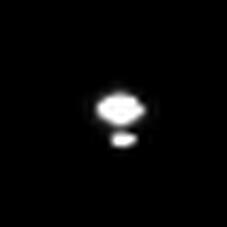
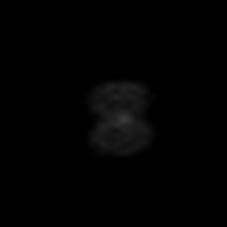
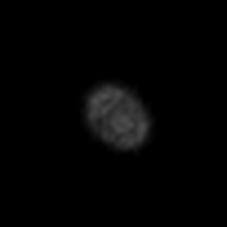
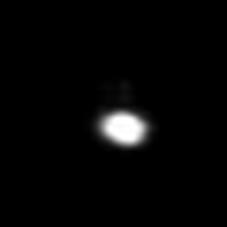
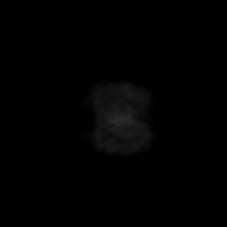
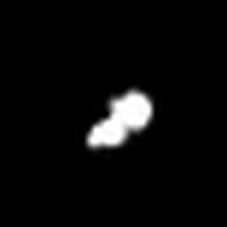
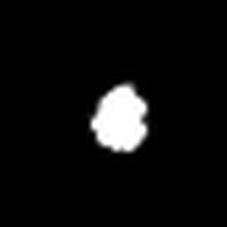
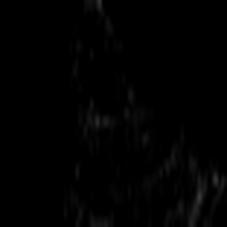
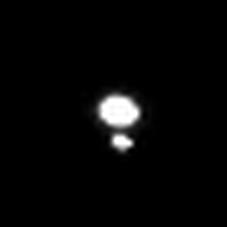
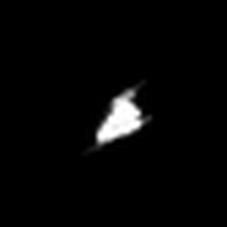
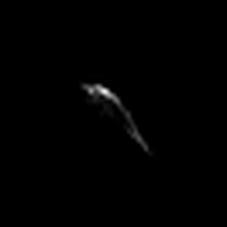
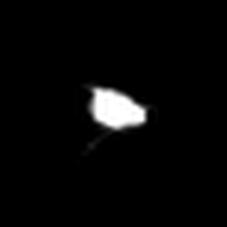
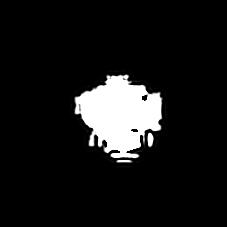
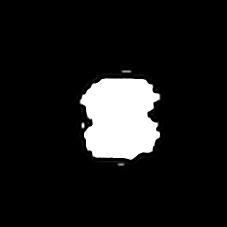
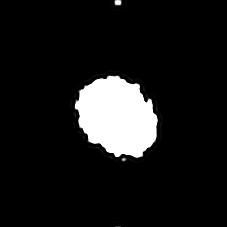
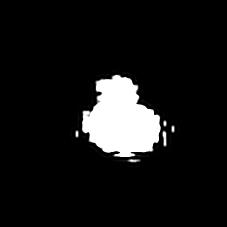
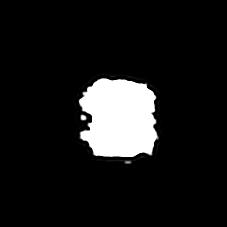
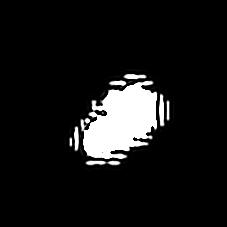
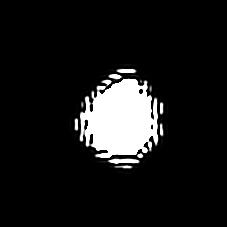
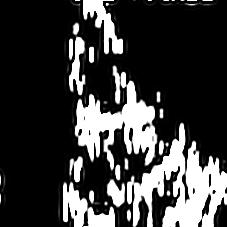
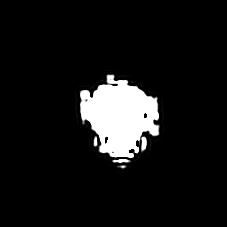
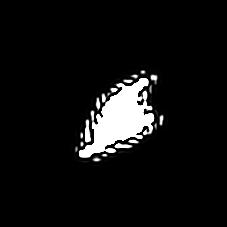
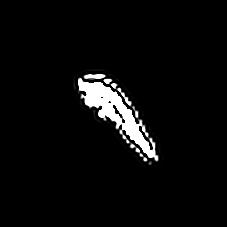
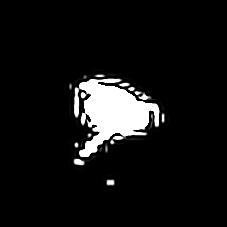
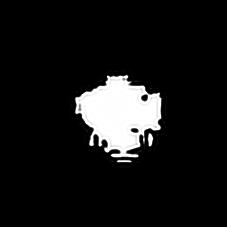
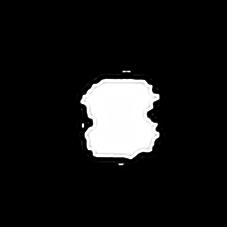
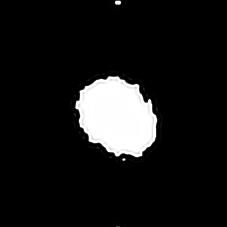
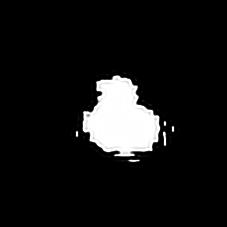
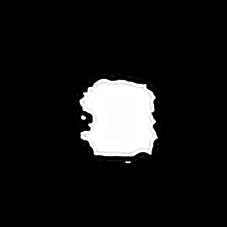
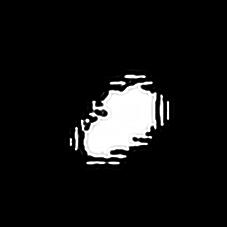
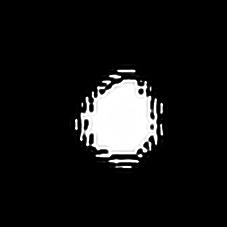
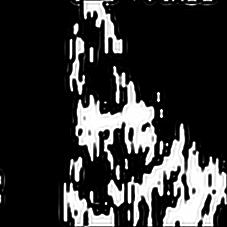
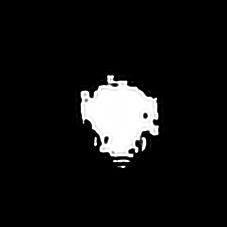
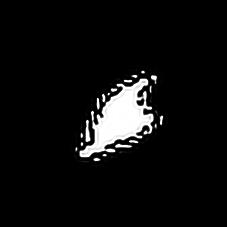
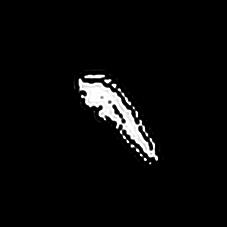
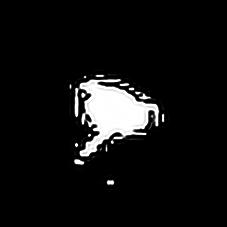

In [26]:
pipeline.images

## Adding a new step manually

You can add a step manually to the pipeline by usign the function "add_step", as you can see in the example below.

If you set the flag substitute to tro, it will remove the step "1" to the new step created

In [27]:
# Add a new step to your process
pipeline.add_step(
    "Area1",
    SamplingLayer,
    {"mode": "fixed", "params": {"value": 10}, "test": False},
    1,
    substitute=True,
)

In [28]:
pipeline

In [29]:
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'raw',
   'sample_data': 'plankton_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/plankton_csv/images'),
   'output_path': PosixPath('output'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/plankton_csv/metadata/metadata_plankton_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_open_args': 'BMP',
   'n_jobs': 1,
   'track_changes': True,
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'test': False,
     'params': {'value': 0.9, 'raise_error': False},
     'mode': 'percent'}]}),
 ('Area1',
  paidiverpy.sampling_layer.sampling_layer.SamplingLayer,
  {'mode': 'fixed',
   'params': {'value': 10},
   'test': False,
   'name': 'Area1',
   'step_name': 'sampling'}),
 ('edge_detection',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'name': 'edge_detection',
   'step_name': 'colour',
   'test': False,
   'params': {'method': 'scharr',
 

In [30]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:15 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:15 | Running step 1: Area1 - SamplingLayer


INFO:paidiverpy:Running step 1: Area1 - SamplingLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:15 | Number of images before the sampling step: 52. Total number of images after: 10


...

INFO:paidiverpy:Step 1 completed


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:15 | Running step 2: edge_detection - ColourLayer


INFO:paidiverpy:Running step 2: edge_detection - ColourLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:16 | Step 2 completed


INFO:paidiverpy:Step 2 completed



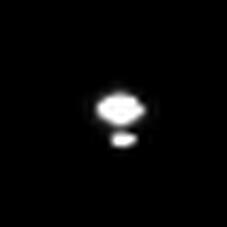
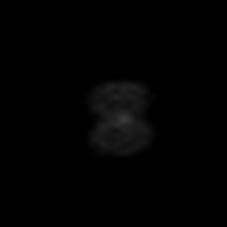
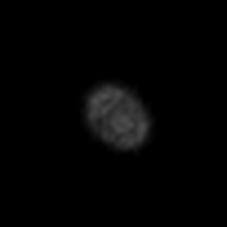
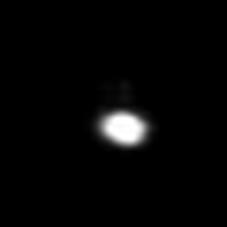
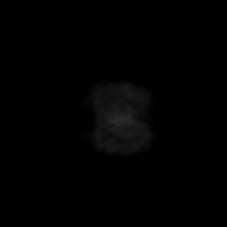
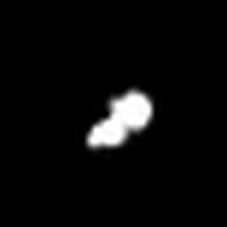
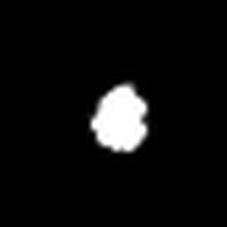
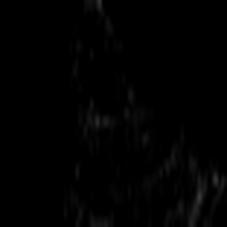
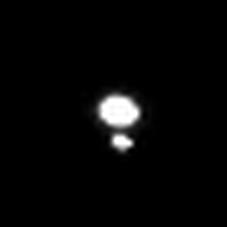
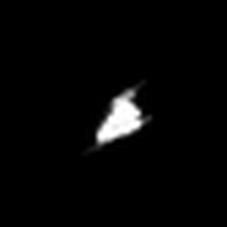
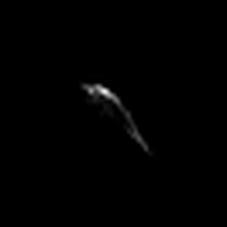
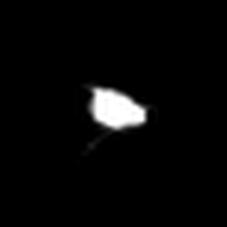
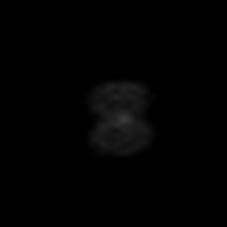
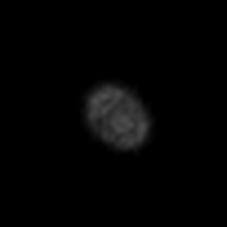
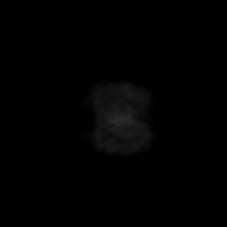
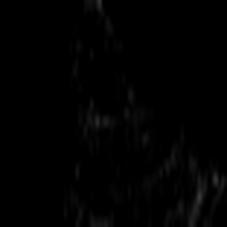
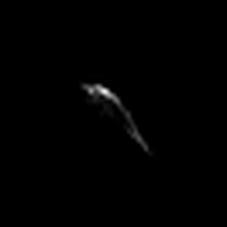
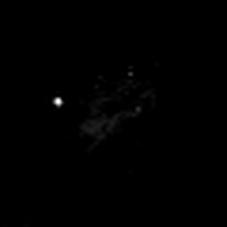
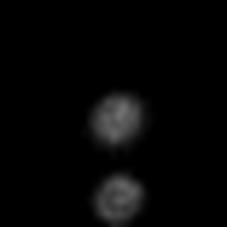
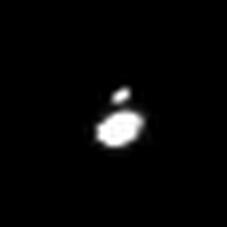
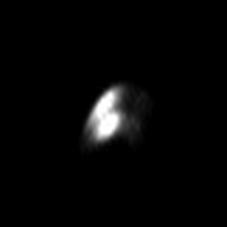
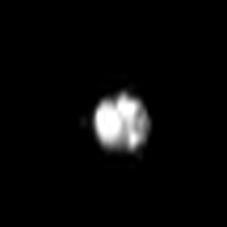
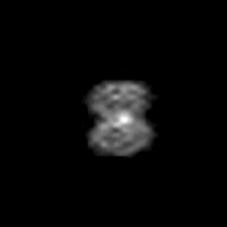
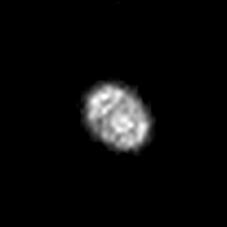
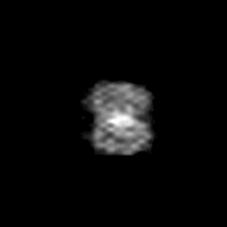
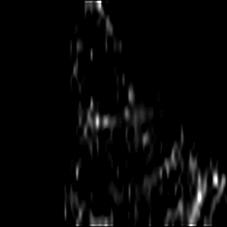
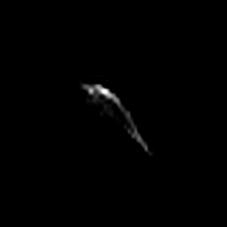
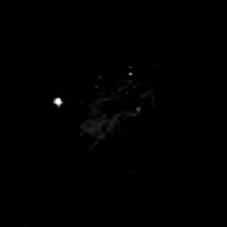
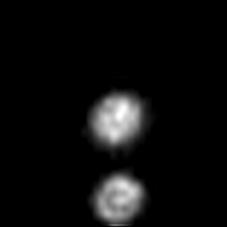
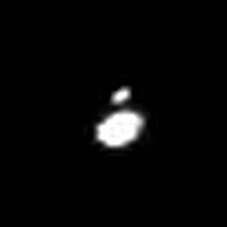
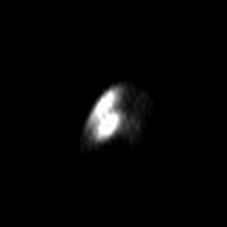
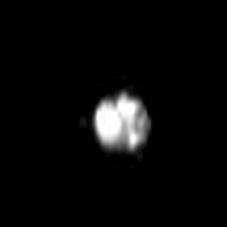

In [31]:
pipeline.images

In the code below, instead of replacing a step, I am just adding a new step

In [32]:
# Add a new step to your process
pipeline.add_step("contrast", ColourLayer, {"mode": "contrast"})

In [33]:
pipeline

In [34]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:17 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:17 | Running step 3: contrast - ColourLayer


INFO:paidiverpy:Running step 3: contrast - ColourLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:17 | Step 3 completed


INFO:paidiverpy:Step 3 completed



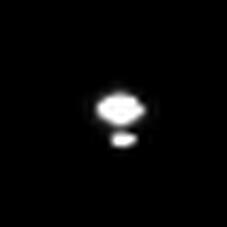
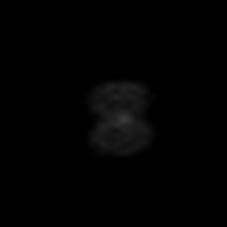
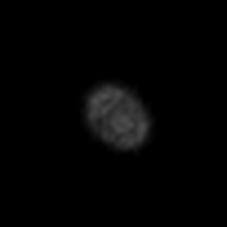
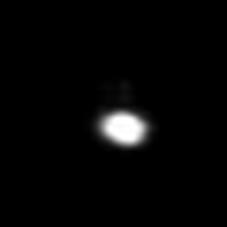
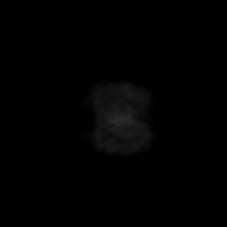
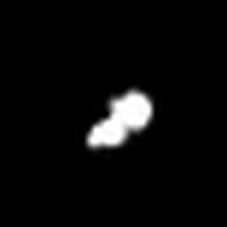
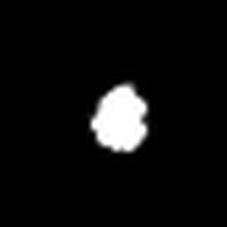
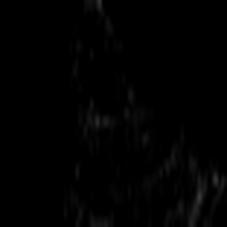
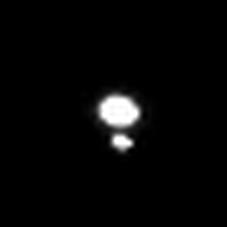
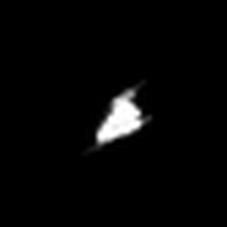
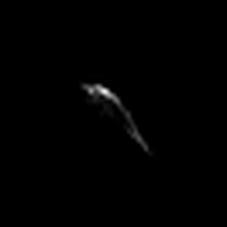
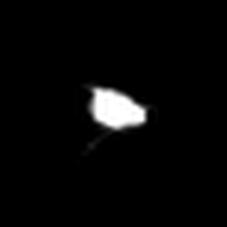
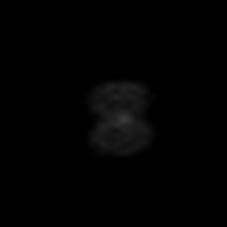
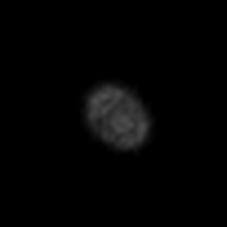
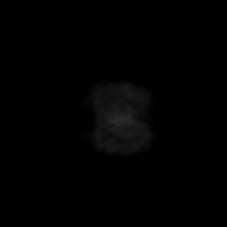
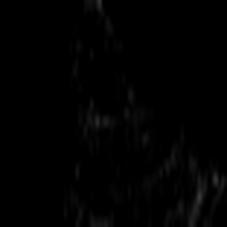
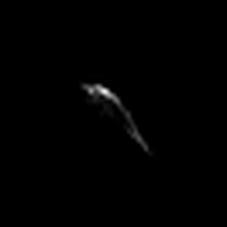
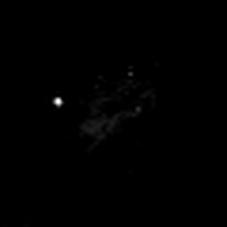
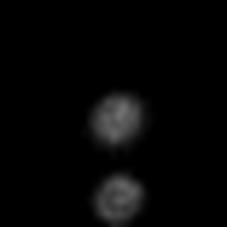
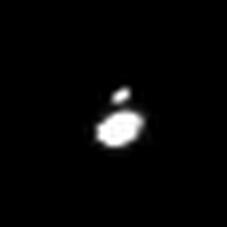
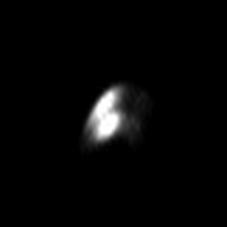
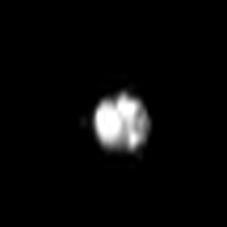
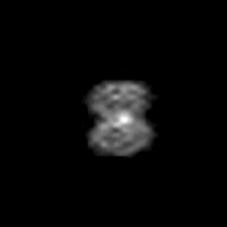
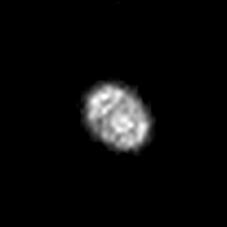
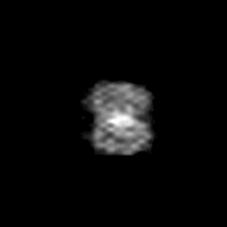
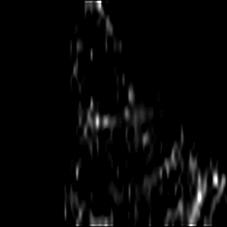
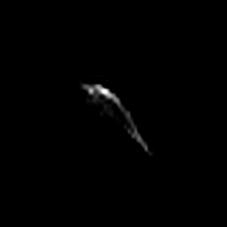
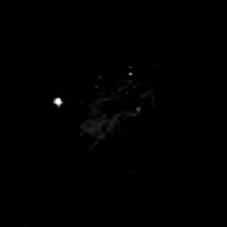
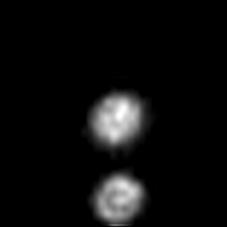
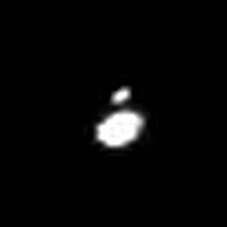
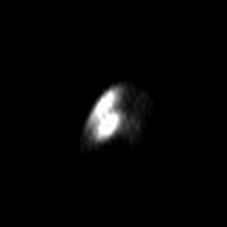
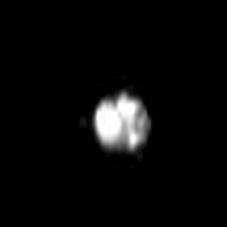
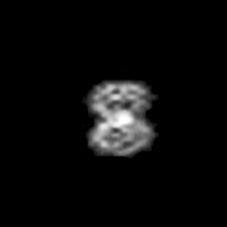
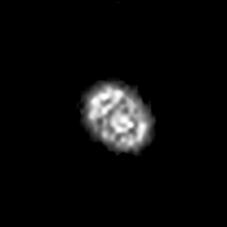
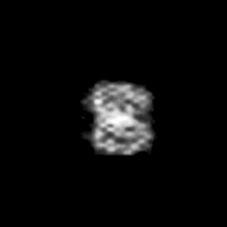
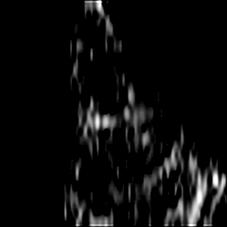
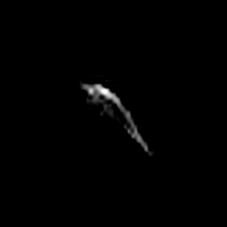
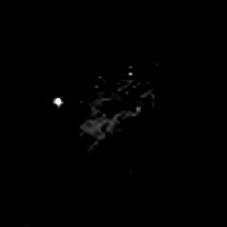
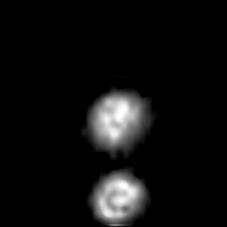
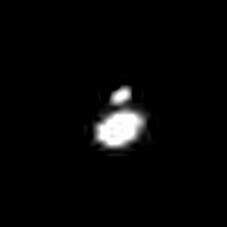
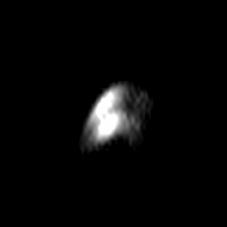
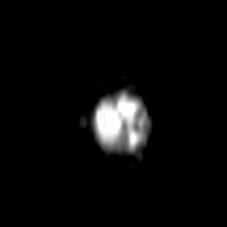

In [35]:
pipeline.images

In [36]:
pipeline.save_images(image_format="png")

☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:17 | Saving images from step: last


INFO:paidiverpy:Saving images from step: last


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:17 | Images are saved to: output


INFO:paidiverpy:Images are saved to: output


## Export the pipeline for a new configuration file

Now you can export the new pipeline to a configuration file and use it to run the pipeline and have the same result

In [37]:
pipeline.export_config("new_config_plankton.yml")

In [38]:
pipeline = Pipeline(config_file_path="new_config_plankton.yml")

In [39]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:18 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:18 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:18 | Step 0 completed


...

INFO:paidiverpy:Step 2 completed


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:20 | Running step 3: contrast - ColourLayer


INFO:paidiverpy:Running step 3: contrast - ColourLayer


☁ paidiverpy ☁  |       INFO | 2025-09-11 16:52:20 | Step 3 completed


INFO:paidiverpy:Step 3 completed



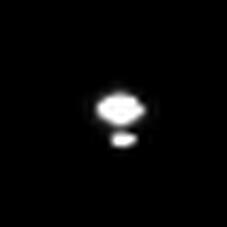
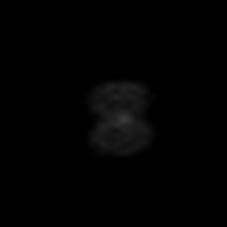
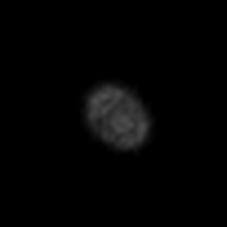
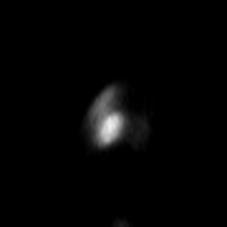
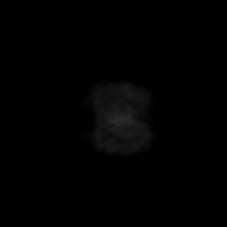
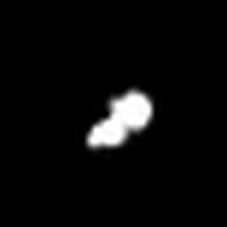
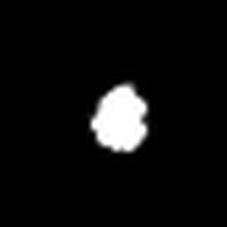
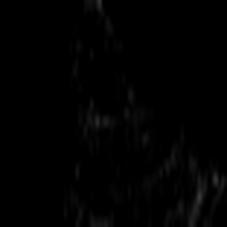
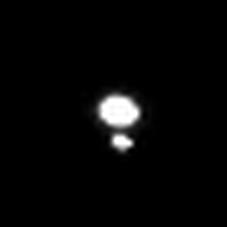
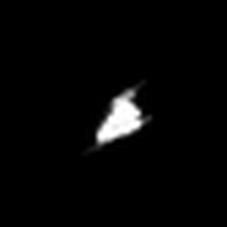
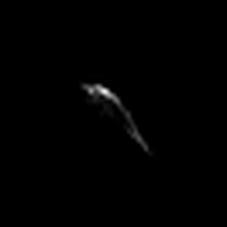
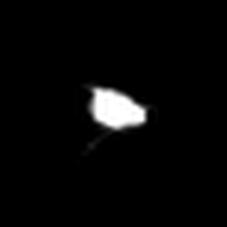
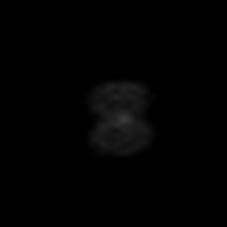
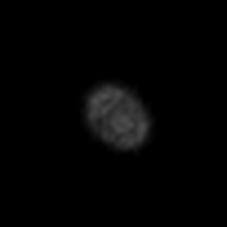
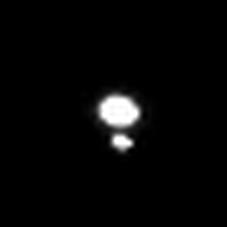
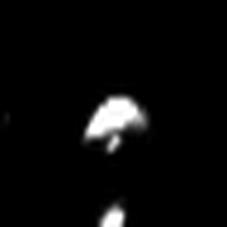
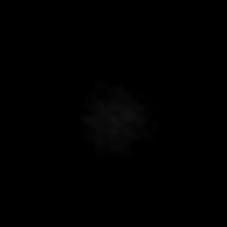
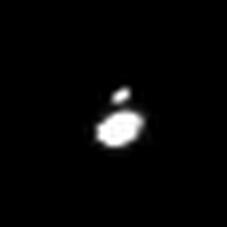
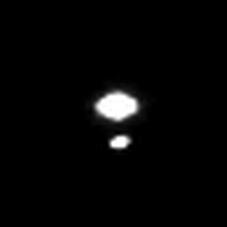
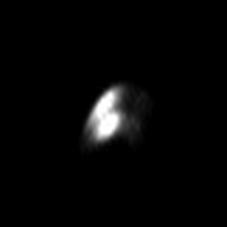
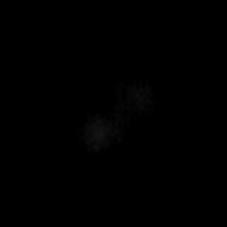
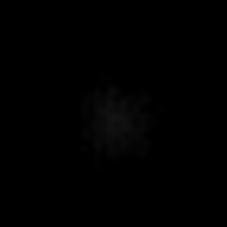
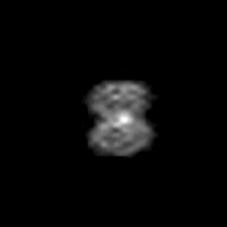
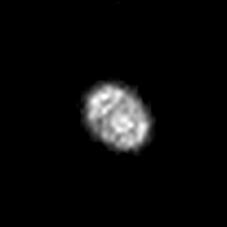
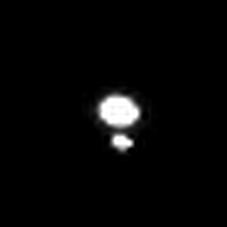
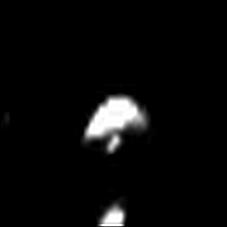
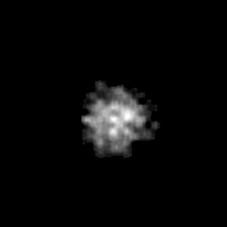
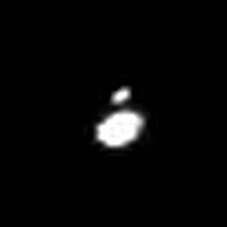
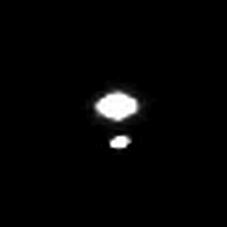
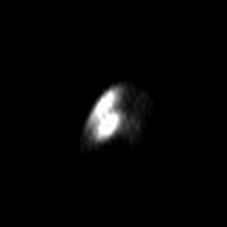
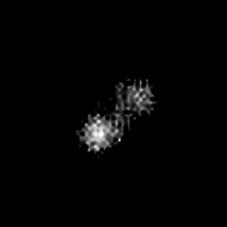
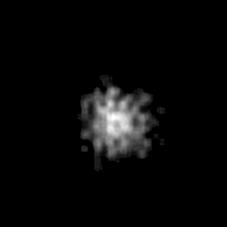
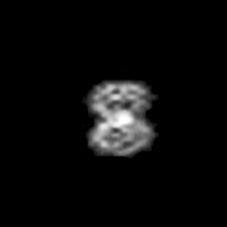
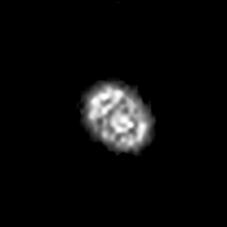
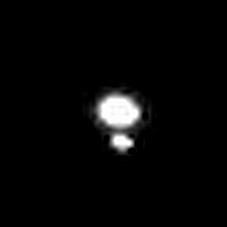
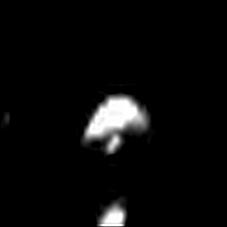
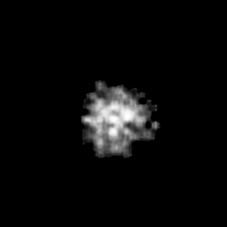
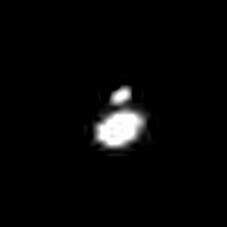
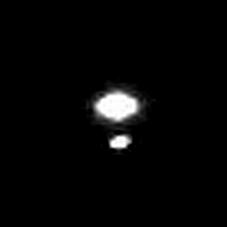
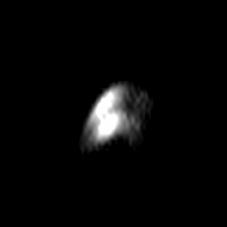
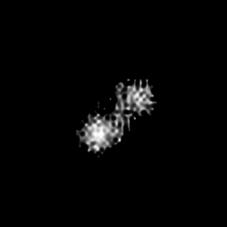
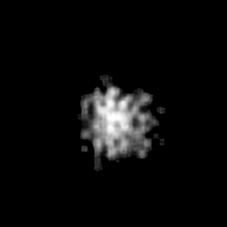

In [40]:
pipeline.images